Volcanic Potential: OTOC & Quantum Chaos Analysis

Objective: This notebook analyzes the Out-of-Time-Order Correlator (OTOC) for a particle in a "Volcano" potential ($V(x) \sim \cosh^{2\nu} + \text{sech}^2$). It compares the quantum scrambling rate against classical and semi-classical Lyapunov exponents to identify regions of local instability vs. global confinement.

How to use: Adjust parameters in the Configuration cell below.Run all cells to generate the Time-Evolution and Quantum-Classical Correspondence plots.

Imports and Configurations

In [211]:
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.cm as cm
from scipy.optimize import curve_fit
from scipy.optimize import brentq
from scipy.optimize import newton

# --- USER CONFIGURATION ---

# 1. Potential Parameters
# NOTE: For nu > 0 (Confining), a1 MUST be negative to ensure Hermiticity (Hard Walls).
a1 = -0.002      
a2 = 100.0        # Depth of the central well
nu = 1.0         # Steepness of the confining walls

# 2. Grid Parameters
L = 10.0         # Spatial extent [-L, L]
N = 1000         # Grid resolution 

# 3. Simulation Parameters
mass = 1.0
t_max = 150.0    # Total simulation time
n_states_sim = 60 # Number of eigenstates to simulate OTOC for (0 to n)

# 4. Analysis & Plotting
limit_n_plot = 30      
fit_window = (0.5, 25.0) 

print(f"System Configured:\nGrid: [-{L}, {L}] ({N} pts)\nPotential: a1={a1}, a2={a2}, nu={nu}")

System Configured:
Grid: [-10.0, 10.0] (1000 pts)
Potential: a1=-0.002, a2=100.0, nu=1.0


Math functions

In [212]:
def sech(x):
    return 1.0 / np.cosh(x)

def build_Grid(L, N):
    x = np.linspace(-L, L, N)
    dx = x[1] - x[0]
    return x, dx

def volcano_potential(x, a1, a2, nu):
    """Returns V(x) for the Hamiltonian construction."""
    cosh_term = np.cosh(x)
    sech_term = sech(x)
    return -1 * ((a1 * (cosh_term)**(2 * nu)) + (a2 * (sech_term)**2))

def volcano_derivatives(x, a1, a2, nu):
    """
    Returns V, V', and V'' for Sensitivity Analysis.
    """
    cosh_x = np.cosh(x)
    sinh_x = np.sinh(x)
    tanh_x = sinh_x / cosh_x
    sech_x = 1 / cosh_x

    # Potential V
    V = -1 * ((a1 * (cosh_x)**(2 * nu)) + (a2 * (sech_x)**2))

    # First Derivative V'
    dV1 = a1 * (2 * nu) * (cosh_x ** (2 * nu - 1)) * sinh_x
    dV2 = a2 * (-2) * (sech_x ** 2) * tanh_x
    V_prime = -(dV1 + dV2)

    # Second Derivative V''
    d2V1 = 2 * nu * a1 * ((2 * nu - 1) * (cosh_x**(2 * nu - 2))*(sinh_x**2) + cosh_x**(2*nu))
    d2V2 = -2*a2 * (sech_x**2) * (-2 * (tanh_x**2) + (sech_x**2))
    V_double_prime = -(d2V1 + d2V2)

    return V, V_prime, V_double_prime

Hamiltonian Solver (DVR)

In [213]:
def solve_schrodinger(x, dx, V_array):
    """Diagonalizes the Hamiltonian using Finite Difference method."""
    size = len(x)
    array = np.ones(size)
    array_off = np.ones(size - 1)
    
    V_matrice = np.diag(V_array)
    # Kinetic Energy Matrix (Finite Difference)
    T_matrice = (2*np.diag(array, k=0) - np.diag(array_off, k=1) - np.diag(array_off, k=-1)) / (2 * dx * dx)
    H_matrice = T_matrice + V_matrice
    
    eigenvalue, eigenvector = np.linalg.eigh(H_matrice)
    return eigenvalue, eigenvector

def energy_matrices(x, dx, nu):
    """Builds Position and Momentum operators in the Energy Basis."""
    V_array = volcano_potential(x, a1, a2, nu)
    
    # 1. Position Operator (Position Basis)
    x_pos_matrice = np.diag(x)
    
    # 2. Momentum Operator (Position Basis)
    size = len(x)
    array_off = np.ones(size - 1)
    P_pos_matrice = -1j * (np.diag(array_off, k=1) - np.diag(array_off, k=-1)) / (2 * dx)
    
    # 3. Diagonalize
    eigenvalue, eigenvector = solve_schrodinger(x, dx, V_array)

    # 4. Transform Operators to Energy Basis
    x_matrice = eigenvector.T @ x_pos_matrice @ eigenvector
    p_matrice = eigenvector.T @ P_pos_matrice @ eigenvector

    return x_matrice, p_matrice, eigenvalue

OTOC Simulation Logic

In [ ]:
def run_simulation_fast(N, t_max, n_state, nu):
    """
    Ultra-fast OTOC simulation using fully vectorized Matrix-Matrix multiplication.
    Eliminates the Python time-loop entirely.
    """
    # 1. Build Grid and Basis (Same as before)
    x, dx = build_Grid(L, N)
    x_E, p_E, energies = energy_matrices(x, dx, nu) 
    
    # 2. Setup Time Evolution Arrays
   
    t_range = np.linspace(0, t_max, 300)
    
  
    p_n = p_E[:, n_state] # Vector shape (N,)
    x_n = x_E[:, n_state] # Vector shape (N,)
    
    # 4. Vectorized Heisenberg Evolution

    E_t = energies[:, None] * t_range[None, :]
    

    phase_minus = np.exp(-1j * E_t) # Shape (N, T)
    phase_plus  = np.exp(1j * E_t)  # Shape (N, T)
    
    # --- Term 1: X(t) P |n> ---
   
    v1 = p_n[:, None] * phase_minus  # Shape (N, T)
    
    # Matrix-Matrix Multiplication: X @ v1
    
    y1 = x_E @ v1  # Shape (N, T)
    
   
    term1 = y1 * phase_plus # Shape (N, T)
    
    # --- Term 2: P X(t) |n> ---
   
    v2 = x_n[:, None] * phase_plus # Shape (N, T)
    
   
    y2 = p_E @ v2 # Shape (N, T)
    
    # Apply outer phase exp(-i E_n t) 
    phase_n = np.exp(-1j * energies[n_state] * t_range)
    term2 = y2 * phase_n[None, :] # Shape (N, T)
    
    # 5. Compute OTOC Intensity
 
    comm_matrix = term1 - term2
    
    # Sum of modulus squared down the column (spatial basis) for each time step
    otoc_values = np.sum(np.abs(comm_matrix)**2, axis=0)

    return otoc_values

def get_otoc_growth_rates(time_array, otoc_data_list, fit_window=None):
    """
    Calculates the MAXIMUM instantaneous growth rate (d/dt log(C)).
    Captures the transient burst of instability.
    """
    rates = []
    dt = time_array[1] - time_array[0]
    window_size = 3 
    
    print(f"Extracting MAX instantaneous growth rates from {len(otoc_data_list)} states...")
    
    for otoc_series in otoc_data_list:
        # Clean Data
        y_clean = np.maximum(np.array(otoc_series), 1e-15)
        log_y = np.log(y_clean)
        
        # Derivative d(ln C)/dt
        d_log_dt = np.gradient(log_y, dt)
        
        # Smoothing
        smoothed_rate = np.convolve(d_log_dt, np.ones(window_size)/window_size, mode='valid')
        
        # Find Max Rate in early time (first 50 units)
        search_limit_idx = np.searchsorted(time_array, 50.0) 
        if len(smoothed_rate) > search_limit_idx:
             max_rate = np.max(smoothed_rate[:search_limit_idx])
        else:
             max_rate = np.max(smoothed_rate)
        
        # Filter numerical noise
        if np.max(y_clean) < 1e-5:
            rates.append(0.0)
        else:
            rates.append(max(0, max_rate))
            
    return np.array(rates)

## Robust Sensitivity Analysis
Uses brentq (bracketing method) as primary root-finder for maximum reliability across all nu values.

In [215]:
# ===== ANALYTICAL POTENTIAL FUNCTIONS =====

def V_analytical(r, a1, a2, nu):
    """Analytical volcano potential: V(r) = -(a1 * cosh^(2nu) + a2 * sech^2)"""
    return -(a1 * np.cosh(r)**(2*nu) + a2 * (1/np.cosh(r))**2)

def dV1_analytical(r, a1, a2, nu):
    """First derivative V'(r)"""
    term1 = 2 * nu * a1 * (np.cosh(r)**(2*nu - 1)) * np.sinh(r)
    term2 = -2 * a2 * (1/np.cosh(r))**2 * np.tanh(r)
    return -(term1 + term2)

def dV2_analytical(r, a1, a2, nu):
    """Second derivative V''(r)"""
    term1_prime = 2*nu*a1 * ( (2*nu*np.cosh(r)**(2*nu) - (2*nu-1)*np.cosh(r)**(2*nu-2)) ) 
    term2_prime = 2*a2 * ( 3*(1/np.cosh(r))**4 - 2*(1/np.cosh(r))**2 )
    return -(term1_prime) + term2_prime

# Legacy compatibility (for older code that uses global parameters)
def dV1(x):
    """First derivative using global parameters a1, a2, nu"""
    return dV1_analytical(x, a1, a2, nu)

def dV2(x):
    """Second derivative using global parameters a1, a2, nu"""
    return dV2_analytical(x, a1, a2, nu)

In [216]:
# ===== ROBUST ROOT FINDING WITH BRENTQ =====

def find_turning_point_brentq(energy, a1, a2, nu, verbose=False):
    """
    Find classical turning point where V(r) = E using Brent's method.
    
    This is THE most robust root-finding method for all nu values.
    Uses adaptive bracketing to handle turning points at any distance.
    
    Strategy:
    1. Determine asymptotic potential limit (depends on nu)
    2. Filter unbound states (E >= V_infinity)
    3. Adaptively find bracket where V(r) - E changes sign
    4. Use brentq (guaranteed convergence within bracket)
    
    Parameters:
    -----------
    energy : float
        Energy of the quantum state
    a1, a2, nu : float
        Potential parameters
    verbose : bool
        Print diagnostic information
    
    Returns:
    --------
    r_c : float or None
        Classical turning point, or None if not found (unbound state)
    """
    
    def objective(r):
        """Function whose root we seek: V(r) - E = 0"""
        return V_analytical(r, a1, a2, nu) - energy
    

    if nu == 0:
        V_inf = -a1  
    elif nu < 0:
        V_inf = 0.0  
    else:  # nu > 0
        V_inf = np.inf  
    
  
    if not np.isinf(V_inf) and energy >= V_inf:
        if verbose:
            print(f"  Unbound state: E={energy:.4f} >= V_inf={V_inf:.4f}")
        return None
    
   
    r_min = 0.01  
    
    
    if nu <= 0 and not np.isinf(V_inf):
        energy_gap = abs(energy - V_inf)
        if energy_gap < 0.0001:
            r_max = 150.0  # Very close to continuum
        elif energy_gap < 0.001:
            r_max = 100.0
        elif energy_gap < 0.01:
            r_max = 50.0
        elif energy_gap < 0.1:
            r_max = 30.0
        elif energy_gap < 1.0:
            r_max = 20.0
        else:
            r_max = 15.0
    else:
        r_max = 15.0  # Default for nu > 0
    
 
    r_left = r_min
    r_right = 0.5  
    
    max_attempts = 30
    for attempt in range(max_attempts):
        try:
            y_left = objective(r_left)
            y_right = objective(r_right)
            
           
            if y_left * y_right < 0:
                # Use brentq - guaranteed to converge within bracket
                r_c = brentq(objective, r_left, r_right, xtol=1e-10, maxiter=100)
                
              
                residual = abs(objective(r_c))
                if residual < 1e-6:
                    if verbose:
                        print(f"  ✓ Found r_c = {r_c:.6f} (bracket: [{r_left:.3f}, {r_right:.3f}], residual: {residual:.2e})")
                    return r_c
            
           
            r_right = min(r_right * 1.8, r_max)
            
          
            if r_right >= r_max:
                break
                
        except Exception as e:
            if verbose:
                print(f"  Exception at attempt {attempt}: {e}")
            r_right = min(r_right * 1.8, r_max)
            continue
    
  
    try:
        y_left = objective(r_min)
        y_right = objective(r_max)
        
        if y_left * y_right < 0:
            r_c = brentq(objective, r_min, r_max, xtol=1e-10, maxiter=100)
            residual = abs(objective(r_c))
            if residual < 1e-6:
                if verbose:
                    print(f"  ✓ Found r_c = {r_c:.6f} (full range [{r_min:.3f}, {r_max:.3f}])")
                return r_c
    except Exception as e:
        if verbose:
            print(f"  Final attempt failed: {e}")
    
    # Could not find turning point
    if verbose:
        print(f"  ✗ No turning point found for E={energy:.4f}")
    return None

In [217]:
# ===== SENSITIVITY CALCULATORS =====

def calculate_lambda_semiclassical(energy, a1, a2, nu, mu=1.0, verbose=False):
    """
    Calculate semi-classical Lyapunov exponent using Airy correction.
    
    FIXED: Now handles cases where Airy correction breaks down!
    
    The Airy correction assumes V(r) is approximately linear near r_c.
    This breaks down when:
    - V'(r_c) is very small (flat potential)
    - r_bar becomes unreasonably large
    - r_m = r_c - r_bar becomes negative
    
    For such cases, we fall back to classical evaluation at r_c.
    
    Formula from paper: λ_sc = sqrt(|V''(r_m)| / μ)
    where r_m = r_c - r_bar is the Airy-corrected position.
    
    Parameters:
    -----------
    energy : float
        Energy eigenvalue of the state
    a1, a2, nu : float
        Potential parameters
    mu : float
        Reduced mass (default 1.0)
    verbose : bool
        Print diagnostic info
    
    Returns:
    --------
    lambda_sc : float or nan
        Semi-classical Lyapunov exponent
    """
    
    # Step 1: Find turning point
    r_c = find_turning_point_brentq(energy, a1, a2, nu, verbose=verbose)
    
    if r_c is None:
        return np.nan
    
    # Step 2: Calculate slope at turning point
    V_prime_rc = dV1_analytical(r_c, a1, a2, nu)
    V_double_prime_rc = dV2_analytical(r_c, a1, a2, nu)
    

    L_char = 2.0  # Typical scale
    
  
    slope_threshold = 0.05  # Empirically determined
    
    if abs(V_prime_rc) < slope_threshold:
     
        if verbose:
            print(f"  Airy correction invalid (V'={V_prime_rc:.4e} < {slope_threshold})")
            print(f"  Using classical λ at r_c = {r_c:.4f}")
        
        lambda_sc = np.sqrt(abs(V_double_prime_rc) / mu)
        return lambda_sc
    
    # Step 4: Airy correction (valid regime)
    r_bar = (1.0 / (2.0 * mu * abs(V_prime_rc)))**(1.0/3.0)
    r_m = r_c - r_bar
    
  
    if r_m < 0.1 or r_bar > 2.0 * r_c:
  
        if verbose:
            print(f"  Airy correction unreasonable (r_m={r_m:.4f}, r_bar={r_bar:.4f})")
            print(f"  Using classical λ at r_c = {r_c:.4f}")
        
        lambda_sc = np.sqrt(abs(V_double_prime_rc) / mu)
        return lambda_sc
    
  
    V_double_prime_rm = dV2_analytical(r_m, a1, a2, nu)
    lambda_sc = np.sqrt(abs(V_double_prime_rm) / mu)
    
    if verbose:
        print(f"  r_c={r_c:.4f}, r_bar={r_bar:.4f}, r_m={r_m:.4f}")
        print(f"  V'(r_c)={V_prime_rc:.4e}, V''(r_m)={V_double_prime_rm:+.4f}")
        print(f"  λ_sc={lambda_sc:.4f}")
    
    return lambda_sc


def calculate_lambda_classical(energy, a1, a2, nu, mu=1.0, verbose=False):
    """
    Calculate classical Lyapunov exponent (no Airy correction).
    
    Evaluated directly at classical turning point r_c.
    Formula: λ_c = sqrt(|V''(r_c)| / μ)
    
    Parameters:
    -----------
    energy : float
        Energy eigenvalue
    a1, a2, nu : float
        Potential parameters
    mu : float
        Reduced mass (default 1.0)
    verbose : bool
        Print diagnostic info
    
    Returns:
    --------
    lambda_c : float or nan
        Classical Lyapunov exponent
    """
    
    r_c = find_turning_point_brentq(energy, a1, a2, nu, verbose=verbose)
    
    if r_c is None:
        return np.nan
    
    V_double_prime = dV2_analytical(r_c, a1, a2, nu)
    lambda_c = np.sqrt(abs(V_double_prime) / mu)
    
    if verbose:
        print(f"  r_c={r_c:.4f}, V''(r_c)={V_double_prime:+.4f}, λ_c={lambda_c:.4f}")
    
    return lambda_c

In [218]:
# ===== LEGACY COMPATIBILITY FUNCTIONS =====
# These maintain backward compatibility with any existing code

def turning_point(V, energy, x):
    """
    Legacy wrapper for backward compatibility with old code.
    Now calls the robust brentq-based finder.
    """
    return find_turning_point_brentq(energy, a1, a2, nu)

def find_rm(rc, mu=1.0):
    """
    Calculate Airy-corrected quantum peak position.
    Legacy function for compatibility.
    """
    V_prime = dV1(rc)
    if abs(V_prime) < 1e-14:
        return max(0.01, rc * 0.9)
    r_bar = (1.0 / (2.0 * mu * abs(V_prime)))**(1.0/3.0)
    rm = rc - r_bar
    return max(0.01, rm)

def semi_classical_sensitivity(v, x, energy, mu=1.0):
    """
    Legacy wrapper for backward compatibility.
    Now uses robust brentq-based calculation.
    """
    return calculate_lambda_semiclassical(energy, a1, a2, nu, mu)

def get_lambda_sc_for_state(energy, a1, a2, nu, mu=1.0):
    """
    Wrapper function used in plotting code.
    Calculates semi-classical sensitivity for a given energy state.
    """
    return calculate_lambda_semiclassical(energy, a1, a2, nu, mu)

## Test Sensitivity Calculations
Verify that root-finding works across all nu regimes

In [219]:
print("="*70)
print("TESTING SENSITIVITY CALCULATIONS")
print("="*70)
print(f"\nCurrent parameters: a1={a1}, a2={a2}, nu={nu}\n")

# Test with a range of energies
if nu > 0:
    test_energies = [-5.0, -2.0, 0.0, 5.0, 10.0]
elif nu == 0:
    test_energies = [-5.0, -2.0, -0.5, -0.1, -0.01]
else:  # nu < 0
    test_energies = [-5.0, -2.0, -1.0, -0.1, -0.01, -0.001]

print("Energy    | r_c        | Classical λ_c | Semi-classical λ_sc")
print("-"*70)

for E in test_energies:
    lambda_c = calculate_lambda_classical(E, a1, a2, nu)
    lambda_sc = calculate_lambda_semiclassical(E, a1, a2, nu)
    
    # Find turning point for display
    r_c = find_turning_point_brentq(E, a1, a2, nu)
    r_c_str = f"{r_c:.6f}" if r_c is not None else "NOT FOUND"
    lambda_c_str = f"{lambda_c:.6f}" if not np.isnan(lambda_c) else "   nan   "
    lambda_sc_str = f"{lambda_sc:.6f}" if not np.isnan(lambda_sc) else "   nan   "
    
    print(f"{E:8.4f}  | {r_c_str:10s} | {lambda_c_str:13s} | {lambda_sc_str:19s}")

print("\n" + "="*70)
print("✓ Test complete! If you see values (not all nan), root-finding works!")
print("="*70)

TESTING SENSITIVITY CALCULATIONS

Current parameters: a1=-0.002, a2=100.0, nu=1.0

Energy    | r_c        | Classical λ_c | Semi-classical λ_sc
----------------------------------------------------------------------
 -5.0000  | 2.174216   | 4.298848      | 5.887975           
 -2.0000  | 2.620569   | 2.782184      | 4.458920           
  0.0000  | 3.396972   | 0.089443      | 2.436445           
  5.0000  | 4.609024   | 4.471699      | 3.058395           
 10.0000  | 4.952691   | 6.324241      | 4.712185           

✓ Test complete! If you see values (not all nan), root-finding works!


Sensitivity Analysis Logic

In [220]:
def dV1(x):
    term1 = -2*nu*a1 * ((np.cosh(x))**(2*nu - 1)) * np.sinh(x)
    term2 = 2*a2 * (sech(x)**2) * np.tanh(x)

    return term1 + term2

def dV2(x):
    term1 = -2*nu*a1*(2*nu*(np.cosh(x)**(2*nu)) - (2*nu - 1)*(np.cosh(x)**(2*nu - 2)))
    term2 = 2*a2*(3*(sech(x)**4) - 2*(sech(x)**2))

    return term1 + term2

In [221]:
def find_rm(rc, mu = 1.0):
    r_bar = (1 / (2 * mu * dV1(rc))**(1/3))
    rm = rc - r_bar
    return rm

def semi_classical_sensitivity(v, x, energy, mu = 0.5):
    rc = turning_point(v, energy, x)
    if rc is None:
        return np.nan
    
    rm = find_rm(rc)
    lambda_sc = np.sqrt((np.abs(dV2(rm)) / mu))

    return lambda_sc


Main Execution Loop

In [222]:
#NOTE: Once this has been executed, no need to execute again

# 1. Run Quantum Simulation
print(f"Starting Fast OTOC Simulation for {n_states_sim} states...")
OTOC_list = []
n_range = range(n_states_sim)

for n in n_range:
    res = run_simulation_fast(N, t_max, n, nu)
    OTOC_list.append(np.real(res))
    if n % 10 == 0: print(f"  Finished State n={n}")

# 2. Extract Growth Rates
t_range = np.linspace(0, t_max, 300)
otoc_slopes = get_otoc_growth_rates(t_range, OTOC_list, fit_window)

# 3. Build System for Analysis
x_grid, dx = build_Grid(L, N)
V_grid, _, _ = volcano_derivatives(x_grid, a1, a2, nu)
_, _, energies = energy_matrices(x_grid, dx, nu)

print("Calculation Complete.")

Starting Fast OTOC Simulation for 60 states...
  Finished State n=0
  Finished State n=10
  Finished State n=20
  Finished State n=30
  Finished State n=40
  Finished State n=50
Extracting MAX instantaneous growth rates from 60 states...
Calculation Complete.


Plot 1: Time Evolution

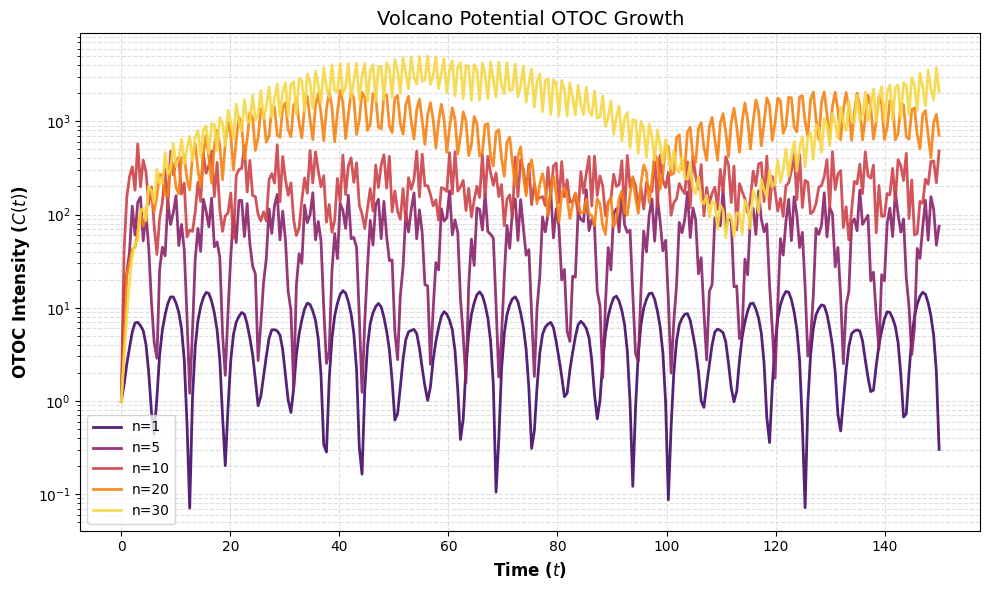

In [223]:
# Plot raw OTOC growth for selected states
plt.figure(figsize=(10, 6), dpi=100)
select_n = [1, 5, 10, 20, 30] # Select a few states to visualize
colors = cm.inferno(np.linspace(0.2, 0.9, len(select_n)))

for i, n in enumerate(select_n):
    if n < len(OTOC_list):
        plt.plot(t_range, OTOC_list[n], label=f'n={n}', color=colors[i], linewidth=2, alpha=0.9)

plt.grid(True, which="both", ls="--", alpha=0.4)  
plt.yscale('log')
plt.xlabel('Time ($t$)', fontsize=12, fontweight='bold')
plt.ylabel('OTOC Intensity ($C(t)$)', fontsize=12, fontweight='bold')
plt.title(f'Volcano Potential OTOC Growth', fontsize=14)
plt.legend(fontsize=10)
plt.tight_layout() 
plt.show()

Calculating Theoretical Sensitivities...
Computing for states n = 0 to 29
  ✓ Calculated states 0-4 (5 valid)
  ✓ Calculated states 0-9 (10 valid)
  ✓ Calculated states 0-14 (15 valid)
  ✓ Calculated states 0-19 (20 valid)
  ✓ Calculated states 0-24 (25 valid)
  ✓ Calculated states 0-29 (30 valid)

✓ Successfully calculated 30 out of 30 states


<>:62: SyntaxWarning: invalid escape sequence '\l'
<>:62: SyntaxWarning: invalid escape sequence '\l'
C:\Users\risha\AppData\Local\Temp\ipykernel_13536\970540840.py:62: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('Growth Rate ($2\lambda$)', fontsize=13)


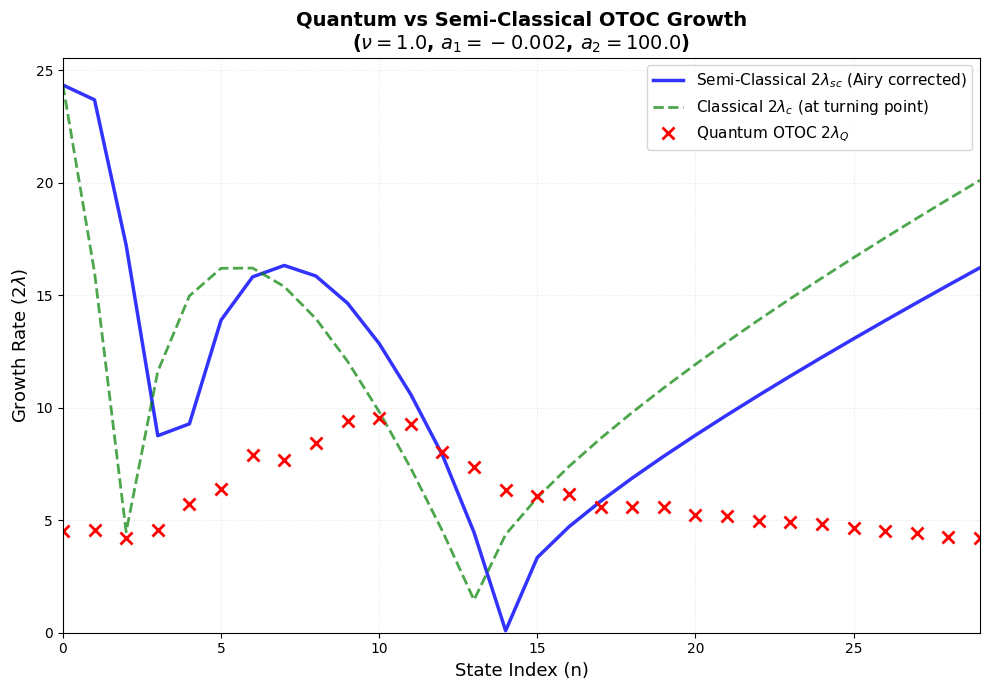


✓ Plot created with 30 semi-classical points


In [224]:
print("Calculating Theoretical Sensitivities...")

n_range = range(min(limit_n_plot, n_states_sim))
lambda_sc_list = []
lambda_c_list = []
valid_n_indices = []

print(f"Computing for states n = 0 to {len(n_range)-1}")

# Calculate sensitivities for each state
for n in n_range:
    E_n = energies[n]
    
    # Semi-classical
    try:
        l_sc = calculate_lambda_semiclassical(E_n, a1, a2, nu)
        if np.isnan(l_sc) or np.isinf(l_sc):
            print(f"  State {n}: E={E_n:.6f} → λ_sc is NaN/Inf (skipping)")
            continue
    except Exception as e:
        print(f"  State {n}: Error in calculation: {e}")
        continue
    
 
    try:
        l_c = calculate_lambda_classical(E_n, a1, a2, nu)
    except:
        l_c = l_sc  # Fallback
    
    lambda_sc_list.append(l_sc)
    lambda_c_list.append(l_c)
    valid_n_indices.append(n)
    
    # Progress indicator every 5 states
    if (n + 1) % 5 == 0:
        print(f"  ✓ Calculated states 0-{n} ({len(valid_n_indices)} valid)")

print(f"\n✓ Successfully calculated {len(valid_n_indices)} out of {len(n_range)} states")

# Convert to arrays
lambda_sc_array = np.array(lambda_sc_list)
lambda_c_array = np.array(lambda_c_list)

# Create the plot
plt.figure(figsize=(10, 7))

# Plot Semi-Classical (blue line)
plt.plot(valid_n_indices, 2 * lambda_sc_array, 'b-', linewidth=2.5, 
         label=r'Semi-Classical $2\lambda_{sc}$ (Airy corrected)', alpha=0.8)

# Plot Classical (green dashed line) 
plt.plot(valid_n_indices, 2 * lambda_c_array, 'g--', linewidth=2, 
         label=r'Classical $2\lambda_{c}$ (at turning point)', alpha=0.7)

# Plot Quantum OTOC results (red crosses)

n_quantum = min(len(valid_n_indices), len(otoc_slopes))
plt.plot(valid_n_indices[:n_quantum], 2 * otoc_slopes[:n_quantum], 'rx', 
         markersize=8, markeredgewidth=2, label=r'Quantum OTOC $2\lambda_{Q}$')

plt.xlabel('State Index (n)', fontsize=13)
plt.ylabel('Growth Rate ($2\lambda$)', fontsize=13)
plt.title(f'Quantum vs Semi-Classical OTOC Growth\n($\\nu={nu}$, $a_1={a1}$, $a_2={a2}$)', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3, linestyle=':')
#plt.xlim(0,15)
plt.xlim(0, max(valid_n_indices) if valid_n_indices else 10)
plt.ylim(bottom=0)

plt.tight_layout()
plt.show()

print(f"\n✓ Plot created with {len(valid_n_indices)} semi-classical points")

Calculating Theoretical Sensitivities...


<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\l'
C:\Users\risha\AppData\Local\Temp\ipykernel_13536\1569837324.py:27: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('Sensitivity Parameter $\lambda$')


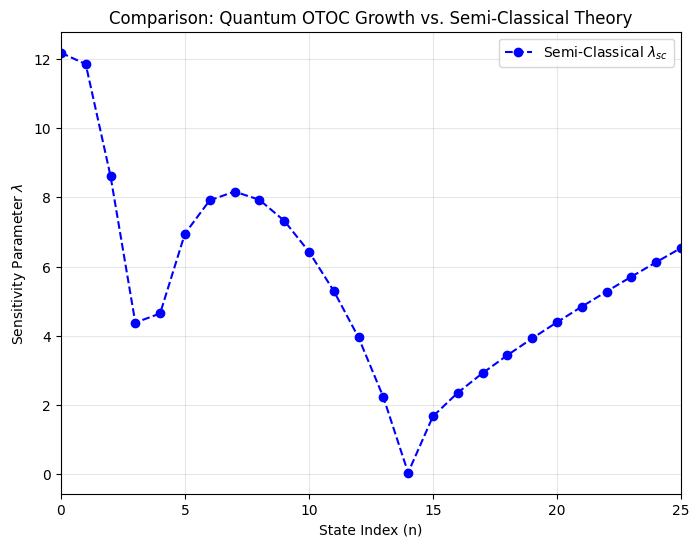

In [225]:
print("Calculating Theoretical Sensitivities...")
lambda_sc_list = []
valid_n_indices = []

# Loop through the states n
for n in n_range:
    E_n = energies[n] # Get the energy eigenvalue for state n
    
    # Calculate semi-classical sensitivity using the CORRECTED function
    l_sc = get_lambda_sc_for_state(E_n, a1, a2, nu)
    
    lambda_sc_list.append(l_sc)
    valid_n_indices.append(n)

# --- Plotting ---
plt.figure(figsize=(8, 6))

# Plot Semi-Classical Sensitivity (Theoretical)
plt.plot(valid_n_indices, lambda_sc_list, 'o--', color='blue', label=r'Semi-Classical $\lambda_{sc}$')

# Plot Your Quantum Simulation Results (Growth Rates)
# Assuming 'otoc_slopes' contains your fitted exponents from the simulation
if 'otoc_slopes' in locals() and len(otoc_slopes) == len(valid_n_indices):
    plt.plot(valid_n_indices, otoc_slopes, 'rx', label=r'Quantum OTOC $\lambda_{Q}$')

plt.xlabel('State Index (n)')
plt.ylabel('Sensitivity Parameter $\lambda$')
plt.title(r'Comparison: Quantum OTOC Growth vs. Semi-Classical Theory')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 25)
plt.show()

Plot 2: Quantum-Classical Correspondence

In [226]:
"""# --- PLOTTING ROUTINE ---

# 1. Theoretical Curves (Scan entire energy range)
# We assume the energy range is bounded roughly by the potential at the wall
E_theory = np.linspace(np.min(energies), np.max(energies), 200)
idx_th, lam_c_th, lam_sc_th = calculate_sensitivities(E_theory, a1, a2, nu, mass, x_max=10.0)
E_theory_plot = E_theory[idx_th]

# 2. Simulation Points (Calculate for specific eigenstates)
idx_sim, lam_c_sim, lam_sc_sim = calculate_sensitivities(energies, a1, a2, nu, mass, x_max=10.0)
sim_energies = energies[idx_sim]

# Filter OTOC rates to match valid indices
sim_rates_filtered = []
for k in idx_sim:
    if k < len(otoc_slopes):
        sim_rates_filtered.append(otoc_slopes[k])
    else:
        sim_rates_filtered.append(np.nan)

# 3. Generate Figure
fig, ax = plt.subplots(figsize=(8, 6), dpi=120)

# Plot Theory
if len(E_theory_plot) > 0:
    ax.plot(E_theory_plot, 2 * lam_c_th, 'b--', alpha=0.6, label=r'Classical Theory ($2\lambda_{cl}$)')
    ax.plot(E_theory_plot, 2 * lam_sc_th, 'g-', linewidth=2, label=r'Semiclassical Theory ($2\lambda_{sc}$)')

# Plot Simulation
if len(sim_energies) > 0:
    ax.scatter(sim_energies, sim_rates_filtered, color='#d62728', s=30, 
               edgecolor='white', linewidth=0.5, label='Simulated OTOC Growth')

ax.set_xlabel(r'Energy ($E$)', fontsize=12)
ax.set_ylabel(r'Lyapunov / Growth Rate', fontsize=12)
ax.set_title(r'Quantum-Classical Correspondence (Hard Wall Enforced)', fontsize=14)
ax.legend(loc='best', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)

# Set limits to focus on the data
if len(energies) > 0:
    ax.set_xlim(np.min(energies), np.max(energies))
ax.set_ylim(bottom=-0.01)
ax.set_xlim(0, 350)
plt.tight_layout()
plt.show()
"""

<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:1: SyntaxWarning: invalid escape sequence '\l'
C:\Users\risha\AppData\Local\Temp\ipykernel_13536\854655061.py:1: SyntaxWarning: invalid escape sequence '\l'
  """# --- PLOTTING ROUTINE ---


"# --- PLOTTING ROUTINE ---\n\n# 1. Theoretical Curves (Scan entire energy range)\n# We assume the energy range is bounded roughly by the potential at the wall\nE_theory = np.linspace(np.min(energies), np.max(energies), 200)\nidx_th, lam_c_th, lam_sc_th = calculate_sensitivities(E_theory, a1, a2, nu, mass, x_max=10.0)\nE_theory_plot = E_theory[idx_th]\n\n# 2. Simulation Points (Calculate for specific eigenstates)\nidx_sim, lam_c_sim, lam_sc_sim = calculate_sensitivities(energies, a1, a2, nu, mass, x_max=10.0)\nsim_energies = energies[idx_sim]\n\n# Filter OTOC rates to match valid indices\nsim_rates_filtered = []\nfor k in idx_sim:\n    if k < len(otoc_slopes):\n        sim_rates_filtered.append(otoc_slopes[k])\n    else:\n        sim_rates_filtered.append(np.nan)\n\n# 3. Generate Figure\nfig, ax = plt.subplots(figsize=(8, 6), dpi=120)\n\n# Plot Theory\nif len(E_theory_plot) > 0:\n    ax.plot(E_theory_plot, 2 * lam_c_th, 'b--', alpha=0.6, label=r'Classical Theory ($2\\lambda_{cl}$)')\n 

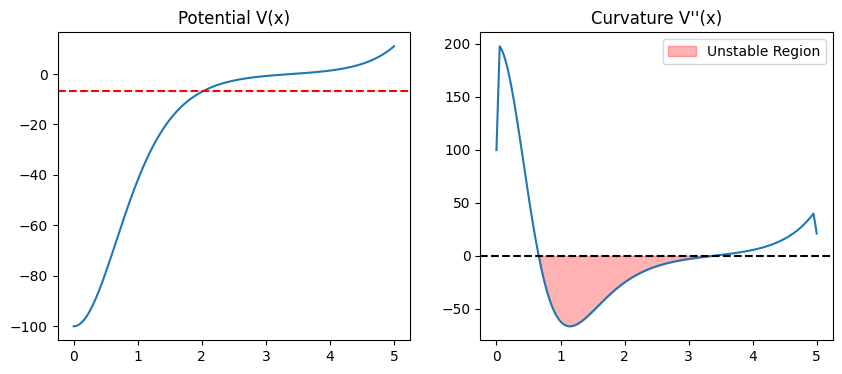

In [227]:
# Quick Diagnostic Plot
import matplotlib.pyplot as plt
x_test = np.linspace(0, 5, 200)
V_test = -(a1 * np.cosh(x_test)**(2*nu) + a2 * (1/np.cosh(x_test))**2)
Curvature_test = np.gradient(np.gradient(V_test, x_test), x_test)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(x_test, V_test)
plt.title("Potential V(x)")
plt.axhline(y=energies[10], color='r', linestyle='--', label=f'E={energies[10]:.1f}') # Check low energy intersection

plt.subplot(1,2,2)
plt.plot(x_test, Curvature_test)
plt.title("Curvature V''(x)")
plt.axhline(0, color='k', linestyle='--')
plt.fill_between(x_test, Curvature_test, 0, where=(Curvature_test < 0), color='red', alpha=0.3, label='Unstable Region')
plt.legend()
plt.show()

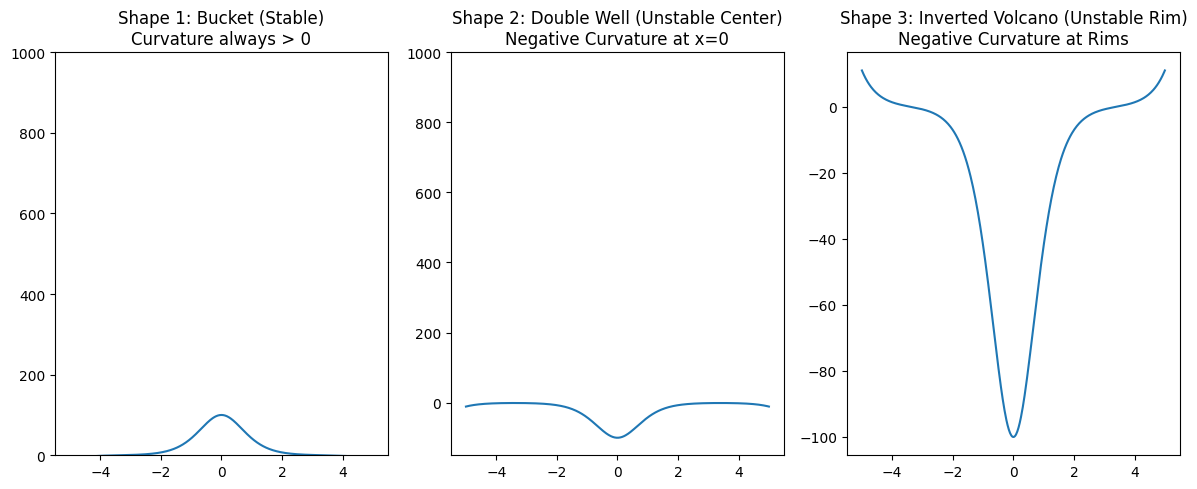

In [228]:
import numpy as np
import matplotlib.pyplot as plt

# Define your parameters
a1_val = a1  # Ensure these are the SAME values used in your simulation
a2_val = a2
nu_val = nu

x = np.linspace(-5, 5, 500)

# Shape 1: The "Bucket" (Likely what you plotted in the diagnostic)
V_bucket = (a1_val * np.cosh(x)**(2*nu_val) + a2_val * (1/np.cosh(x))**2)

# Shape 2: The "Double Well" (Confining with instability at x=0)
# This creates a barrier at the center if parameters are right
V_double = (a1_val * np.cosh(x)**(2*nu_val) - a2_val * (1/np.cosh(x))**2) 

# Shape 3: The "Volcano" (Paper 2 standard, inverted)
V_volcano = -(a1_val * np.cosh(x)**(2*nu_val) + a2_val * (1/np.cosh(x))**2)

# Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.plot(x, V_bucket)
plt.title("Shape 1: Bucket (Stable)\nCurvature always > 0")
plt.ylim(0, 1000) # Adjust view

plt.subplot(1, 3, 2)
plt.plot(x, V_double)
plt.title("Shape 2: Double Well (Unstable Center)\nNegative Curvature at x=0")
plt.ylim(-a2_val*1.5, 1000)

plt.subplot(1, 3, 3)
plt.plot(x, V_volcano)
plt.title("Shape 3: Inverted Volcano (Unstable Rim)\nNegative Curvature at Rims")

plt.tight_layout()
plt.show()